# Airline Route Profitability — Group Notebook
## Phase 1: Data Understanding, Preprocessing & Exploratory Data Analysis

**Framework:** CRISP-DM (Cross-Industry Standard Process for Data Mining)  
**CRISP-DM Phase:** Business Understanding → Data Understanding → Data Preparation  

---

### Business Context
Airlines operate in one of the most cost-intensive and competitively volatile industries in the world.
A single route can mean the difference between survival and insolvency. This project builds a
**binary classification model** to predict whether a given flight/route will be *profitable* or
*loss-making*, enabling airline revenue managers and operations planners to make data-driven
decisions about route viability, capacity planning, and pricing strategy.

This notebook covers **all data preparation steps** — cleaning, leakage prevention, feature
engineering, encoding, scaling, EDA, and train/val/test splitting — before the modelling
notebooks consume the outputs.

## 1. Business Understanding

| Dimension | Detail |
|-----------|--------|
| **Business Problem** | Identify which airline routes are likely to be profitable before or shortly after scheduling |
| **Primary Users** | Revenue Management teams, Network Planning, CFO offices |
| **Business Value** | Reduce loss-making route exposure; optimise capacity allocation; improve load-factor targets |
| **ML Task** | Binary Classification |
| **Target Column** | `Profitable` (1 = profit-making flight, 0 = loss-making) |
| **Dataset** | 15,000 synthetic route-level records, 10 airlines, 2022–2024 |
| **Class Balance** | ~63.7% profitable / ~36.3% loss-making (moderate imbalance) |
| **Imbalance Strategy** | `class_weight='balanced'` in all downstream classifiers |
| **Success Metric** | F1-Score (macro), ROC-AUC, MCC |

---

### CRISP-DM Phase Map

| Phase | Activities in This Project |
|-------|---------------------------|
| Business Understanding | Problem definition, research questions, assumptions, success metrics |
| Data Understanding | Load data, inspect types, prior hypothesis, IC/EC table, EDA |
| Data Preparation | Clean, impute, engineer features, encode, scale, split, save CSVs |
| Modelling | Individual notebooks — RF, XGBoost, SVM, KNN, MLP |
| Evaluation | Cross-group metric comparison in group final notebook |
| Deployment | Streamlit dashboard in group final notebook |

---

### Research Questions

| ID | Question |
|----|----------|
| RQ1 | Which operational features are the strongest predictors of route profitability? |
| RQ2 | Does Load Factor alone provide sufficient signal for binary classification? |
| RQ3 | How strongly does season affect profitability, controlling for route category? |
| RQ4 | Do short-haul routes structurally underperform long-haul routes across all seasons? |
| RQ5 | Which model generalises best to unseen routes while maintaining low false-positive cost? |

---

### Explicit Assumptions

1. **Profit threshold:** `Profitable = 1` if and only if `Profit > 0` — zero-profit flights are classified as loss-making.
2. **Pre-flight scenario:** All features used are observable before or at the time of scheduling — no post-flight financial outcomes included.
3. **Synthetic dataset:** Data is synthetically generated; real-world deployment would require retraining on carrier-specific operational data.
4. **Split rationale:** 80/10/10 train/val/test — val set used for hyperparameter tuning; test set touched only once for final evaluation.
5. **Scaler discipline:** `StandardScaler` fitted on training data only; val and test transformed using training statistics to prevent leakage.
6. **Class imbalance:** 63.7/36.3 split is treated via `class_weight='balanced'`; no oversampling applied to avoid synthetic data amplification on an already synthetic dataset.

---

### Prior Hypothesis (Before Data Inspection)

**Hypothesised included fields:** Load_Factor, Flight_Distance_KM, Aircraft_Capacity, Passengers, Flight_Hours, Season, Demand_Level, Route_Category, Competition_Index, Average_Ticket_Price, Aircraft_Type, Delay_Minutes, Fuel_Price_Per_Liter, On_Time_Performance, Aircraft_Age_Years.

**Hypothesised excluded fields (with IC/EC rationale):**

| Criterion | Field(s) | Exclusion Reason |
|-----------|----------|------------------|
| IC1 — Post-flight financial outcome | Profit, Profit_Margin, Total_Revenue, Total_Cost | Direct derivations of target — data leakage |
| IC2 — Cost component known only post-flight | Fuel_Cost, Crew_Cost, Maintenance_Cost, Depreciation_Cost, Insurance_Cost, Airport_Fees, Catering_Cost, Handling_Cost, Navigation_Fees, Sales_Distribution_Cost, Passenger_Service_Cost, Overhead_Cost, Marketing_Cost, IT_Systems_Cost | Not observable pre-scheduling |
| IC3 — Revenue component known only post-flight | Ticket_Revenue, Ancillary_Revenue, Cargo_Revenue | Not observable pre-scheduling |
| IC4 — Row identifier | Flight_ID, Flight_Number, Route | No predictive signal; would cause memorisation |
| IC5 — High-cardinality string | Origin, Destination, Airline, Origin_Country, Destination_Country | Replaced by engineered region features |

## 2. Setup — Libraries, Constants, Paths

All group-wide constants are fixed here. Every student notebook imports from the same `processed_data/` folder using the same `RANDOM_STATE=42` to guarantee reproducibility.

In [39]:
import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries loaded successfully.')

Libraries loaded successfully.


### Path configuration

All outputs — CSVs, PNGs, JSON, pickle — are written to `processed_data/`. The path resolves relative to the notebook location so it works on any machine.

In [40]:
from pathlib import Path

RANDOM_STATE = 42
TEST_SIZE    = 0.10
VAL_SIZE     = 0.10
TARGET_COL   = 'Profitable'

PROJECT_DIR = Path.cwd()

RAW_DATA_PATH = PROJECT_DIR / 'data' / 'raw' / 'airline_profitability_synthetic_raw.csv'
PROCESSED_DIR = PROJECT_DIR / 'processed_data'
FIG_DIR       = PROCESSED_DIR
os.makedirs(PROCESSED_DIR, exist_ok=True)

C_PROFIT  = '#2DC653'
C_LOSS    = '#E84855'
C_NEUTRAL = '#2E86AB'

print(f'RANDOM_STATE  = {RANDOM_STATE}')
print(f'TEST_SIZE     = {TEST_SIZE}')
print(f'VAL_SIZE      = {VAL_SIZE}')
print(f'TARGET_COL    = {TARGET_COL}')
print(f'Project dir   : {PROJECT_DIR}')
print(f'Raw data path : {RAW_DATA_PATH}')
print(f'Output dir    : {PROCESSED_DIR}')
print(f'Raw file exists: {RAW_DATA_PATH.exists()}')

RANDOM_STATE  = 42
TEST_SIZE     = 0.1
VAL_SIZE      = 0.1
TARGET_COL    = Profitable
Project dir   : c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project
Raw data path : c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project\data\raw\airline_profitability_synthetic_raw.csv
Output dir    : c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project\processed_data
Raw file exists: True


## 3. Data Loading & Initial Inspection

First look at the raw dataset — shape, column names, dtypes, and a sample of rows. This confirms the file loaded correctly and gives an initial sense of field types before any decisions are made.

In [41]:
df_raw = pd.read_csv(RAW_DATA_PATH)
print(f'Shape: {df_raw.shape}')
print(f'Columns ({len(df_raw.columns)}): {list(df_raw.columns)}')
df_raw.head(3)

Shape: (15000, 51)
Columns (51): ['Flight_ID', 'Flight_Number', 'Flight_Date', 'Day_of_Week', 'Airline', 'Alliance', 'Origin', 'Origin_Country', 'Destination', 'Destination_Country', 'Route', 'Flight_Distance_KM', 'Route_Category', 'Aircraft_Type', 'Aircraft_Capacity', 'Aircraft_Age_Years', 'Passengers', 'Load_Factor', 'Flight_Hours', 'Season', 'Demand_Level', 'Competition_Index', 'Weather_Disruption', 'On_Time_Performance', 'Delay_Minutes', 'Average_Ticket_Price', 'Ticket_Revenue', 'Ancillary_Revenue', 'Cargo_Revenue', 'Total_Revenue', 'Fuel_Price_Per_Liter', 'Fuel_Cost', 'Maintenance_Cost', 'Crew_Cost', 'Depreciation_Cost', 'Insurance_Cost', 'Airport_Fees', 'Catering_Cost', 'Handling_Cost', 'Navigation_Fees', 'Sales_Distribution_Cost', 'Passenger_Service_Cost', 'Overhead_Cost', 'Marketing_Cost', 'IT_Systems_Cost', 'Total_Cost', 'Profit', 'Profit_Margin', 'Profitable', 'Passenger_Satisfaction_Score', 'Market_Share_Pct']


,Flight_ID,Flight_Number,Flight_Date,Day_of_Week,Airline,Alliance,Origin,Origin_Country,Destination,Destination_Country,Route,Flight_Distance_KM,Route_Category,Aircraft_Type,Aircraft_Capacity,Aircraft_Age_Years,Passengers,Load_Factor,Flight_Hours,Season,Demand_Level,Competition_Index,Weather_Disruption,On_Time_Performance,Delay_Minutes,Average_Ticket_Price,Ticket_Revenue,Ancillary_Revenue,Cargo_Revenue,Total_Revenue,Fuel_Price_Per_Liter,Fuel_Cost,Maintenance_Cost,Crew_Cost,Depreciation_Cost,Insurance_Cost,Airport_Fees,Catering_Cost,Handling_Cost,Navigation_Fees,Sales_Distribution_Cost,Passenger_Service_Cost,Overhead_Cost,Marketing_Cost,IT_Systems_Cost,Total_Cost,Profit,Profit_Margin,Profitable,Passenger_Satisfaction_Score,Market_Share_Pct
0,FL000001,AF3612,2024-05-10,Friday,Air France,SkyTeam,CDG,France,ATL,USA,CDG-ATL,7520,Long Haul,Airbus A350-900,325,21.0000,245,0.7548,9.7000,Shoulder,Medium,3.0000,0,88.3000,60.0000,493.0000,120785.7000,20360.5600,71184.0000,212330.2600,0.7115,41545.9000,20641.9800,15797.2000,40059.4300,2585.6100,9140.4400,14575.1600,2897.5300,3350.3000,8793.6200,3725.7900,21117.0500,4900.2000,1215.7100,190345.9200,21984.3400,10.3500,1,NaN,14.4000
1,FL000002,BA6892,2022-04-02,Saturday,British Airways,OneWorld,LHR,UK,HKG,Hong Kong,LHR-HKG,9640,Long Haul,Airbus A350-900,325,8.0000,257,0.7911,11.9000,Shoulder,Medium,3.0000,0,97.7000,0.0000,860.8500,221238.8300,14845.6400,11820.3100,247904.7800,0.6993,51143.2000,22610.4200,22173.5200,41639.5800,3182.4800,9426.3500,15245.3500,8279.9400,5093.6900,17031.9800,3245.3400,39778.1000,9796.7600,868.6600,249515.3700,-1610.5900,-0.6500,0,7.7000,30.2000
2,FL000003,CX6592,2024-10-14,Monday,Cathay Pacific,OneWorld,HKG,Hong Kong,LHR,UK,HKG-LHR,9640,Long Haul,Airbus A330-300,277,12.0000,233,0.8440,11.8000,Shoulder,Medium,7.0000,0,NaN,3.0000,947.2600,220710.8700,6881.5200,62351.4400,289943.8300,0.8291,69720.7700,23233.2700,21865.6500,21025.5300,1199.2900,8986.2800,12926.5500,3707.1700,5342.6000,13786.6200,2408.0500,29546.5700,6434.1500,555.6800,220738.1800,69205.6500,23.8700,1,NaN,14.1000


### Data types and null counts

Understanding column dtypes determines the preprocessing strategy: object fields need encoding, numeric fields may need scaling or transformation, date fields need parsing. Null counts drive the imputation decisions in Section 7.

In [42]:
dtype_df = pd.DataFrame({'dtype': df_raw.dtypes, 'null_count': df_raw.isnull().sum(),
                          'null_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)})
print(dtype_df.to_string())

                                dtype  null_count  null_pct
Flight_ID                      object           0    0.0000
Flight_Number                  object           0    0.0000
Flight_Date                    object           3    0.0200
Day_of_Week                    object           0    0.0000
Airline                        object           0    0.0000
Alliance                       object           0    0.0000
Origin                         object           0    0.0000
Origin_Country                 object          12    0.0800
Destination                    object           0    0.0000
Destination_Country            object           0    0.0000
Route                          object           0    0.0000
Flight_Distance_KM              int64           0    0.0000
Route_Category                 object           0    0.0000
Aircraft_Type                  object           0    0.0000
Aircraft_Capacity               int64           0    0.0000
Aircraft_Age_Years            float64   

### Descriptive statistics

Summary stats for all numeric columns — used to identify skewness, plausible value ranges, and outlier candidates before any cleaning is applied.

In [43]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
Flight_Distance_KM,15000.0000,6049.9313,3922.1546,280.0000,2510.0000,5840.0000,8750.0000,16990.0000
Aircraft_Capacity,15000.0000,305.3281,83.9930,180.0000,220.0000,296.0000,325.0000,517.0000
Aircraft_Age_Years,13650.0000,11.0000,6.0511,1.0000,6.0000,11.0000,16.0000,21.0000
Passengers,15000.0000,236.0943,75.6037,54.0000,180.0000,229.0000,277.0000,517.0000
Load_Factor,15000.0000,0.7785,0.1236,0.3026,0.6950,0.7833,0.8647,1.0600
Flight_Hours,15000.0000,7.8695,4.6191,0.8000,3.7000,7.7000,11.2000,21.2000
Competition_Index,14100.0000,5.0083,2.5669,1.0000,3.0000,5.0000,7.0000,9.0000
Weather_Disruption,15000.0000,0.0767,0.2661,0.0000,0.0000,0.0000,0.0000,1.0000
On_Time_Performance,13950.0000,80.3073,11.4101,55.0000,72.8000,82.0000,89.4000,99.9000
Delay_Minutes,13805.0000,9.9689,15.9930,-24.0000,0.0000,2.0000,15.0000,175.0000


## 4. Pre-cleaning Missing Value Report

Documenting null counts **before** any imputation so the cleaning steps can be justified against baseline figures. This table appears in the report as evidence of data quality issues.

In [44]:
null_report = df_raw.isnull().sum()
null_report = null_report[null_report > 0].sort_values(ascending=False)
null_pct    = (null_report / len(df_raw) * 100).round(2)
print('=== Missing Value Report (Before Cleaning) ===')
for col in null_report.index:
    print(f'  {col:<40}: {null_report[col]:>5} nulls ({null_pct[col]:.2f}%)')
print(f'\nTotal null cells: {df_raw.isnull().sum().sum()}')

=== Missing Value Report (Before Cleaning) ===
  Passenger_Satisfaction_Score            :  1800 nulls (12.00%)
  Aircraft_Age_Years                      :  1350 nulls (9.00%)
  Cargo_Revenue                           :  1200 nulls (8.00%)
  Delay_Minutes                           :  1195 nulls (7.97%)
  On_Time_Performance                     :  1050 nulls (7.00%)
  Market_Share_Pct                        :  1050 nulls (7.00%)
  Competition_Index                       :   900 nulls (6.00%)
  Fuel_Price_Per_Liter                    :   750 nulls (5.00%)
  Handling_Cost                           :   750 nulls (5.00%)
  Ancillary_Revenue                       :   750 nulls (5.00%)
  Catering_Cost                           :   750 nulls (5.00%)
  Average_Ticket_Price                    :   595 nulls (3.97%)
  Origin_Country                          :    12 nulls (0.08%)
  Flight_Date                             :     3 nulls (0.02%)

Total null cells: 12155


## 5. Duplicate Check

Removing duplicates prevents the model from seeing identical records in both training and test splits, which would inflate performance metrics.

In [45]:
n_dups = df_raw.duplicated().sum()
print(f'Duplicate rows found: {n_dups}')
df = df_raw.copy()
if n_dups > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'Rows after deduplication: {len(df)}')
else:
    print('No duplicates — dataset integrity confirmed.')

Duplicate rows found: 0
No duplicates — dataset integrity confirmed.


## 6. Drop Leaky Columns

The business scenario is **pre-flight route scoring** — the model must predict profitability before a flight operates. All post-flight financial outcomes (actual revenue, actual costs, profit, profit margin) are therefore excluded as they are unavailable at prediction time and would constitute data leakage. IC1–IC3 in the exclusion criteria table above.

In [46]:
LEAKY_COLS = [
    'Profit', 'Profit_Margin',
    'Total_Revenue', 'Total_Cost',
    'Ticket_Revenue', 'Ancillary_Revenue', 'Cargo_Revenue',
    'Fuel_Cost', 'Maintenance_Cost', 'Crew_Cost', 'Depreciation_Cost',
    'Insurance_Cost', 'Airport_Fees', 'Catering_Cost', 'Handling_Cost',
    'Navigation_Fees', 'Sales_Distribution_Cost', 'Passenger_Service_Cost',
    'Overhead_Cost', 'Marketing_Cost', 'IT_Systems_Cost',
]
leaky_present = [c for c in LEAKY_COLS if c in df.columns]
df.drop(columns=leaky_present, inplace=True)
print(f'Dropped {len(leaky_present)} leaky columns:')
for c in leaky_present:
    print(f'  - {c}')
print(f'\nRemaining columns: {df.shape[1]}')

Dropped 21 leaky columns:
  - Profit
  - Profit_Margin
  - Total_Revenue
  - Total_Cost
  - Ticket_Revenue
  - Ancillary_Revenue
  - Cargo_Revenue
  - Fuel_Cost
  - Maintenance_Cost
  - Crew_Cost
  - Depreciation_Cost
  - Insurance_Cost
  - Airport_Fees
  - Catering_Cost
  - Handling_Cost
  - Navigation_Fees
  - Sales_Distribution_Cost
  - Passenger_Service_Cost
  - Overhead_Cost
  - Marketing_Cost
  - IT_Systems_Cost

Remaining columns: 30


## 7. Drop Identifier Columns

Flight_ID, Flight_Number, and Route are unique row identifiers with no predictive signal. Keeping them would cause the model to memorise row labels rather than learn operational patterns (IC4).

In [47]:
ID_COLS = ['Flight_ID', 'Flight_Number', 'Route']
id_present = [c for c in ID_COLS if c in df.columns]
df.drop(columns=id_present, inplace=True)
print(f'Dropped identifier columns: {id_present}')
print(f'Remaining columns: {df.shape[1]}')
print(f'Columns: {list(df.columns)}')

Dropped identifier columns: ['Flight_ID', 'Flight_Number', 'Route']
Remaining columns: 27
Columns: ['Flight_Date', 'Day_of_Week', 'Airline', 'Alliance', 'Origin', 'Origin_Country', 'Destination', 'Destination_Country', 'Flight_Distance_KM', 'Route_Category', 'Aircraft_Type', 'Aircraft_Capacity', 'Aircraft_Age_Years', 'Passengers', 'Load_Factor', 'Flight_Hours', 'Season', 'Demand_Level', 'Competition_Index', 'Weather_Disruption', 'On_Time_Performance', 'Delay_Minutes', 'Average_Ticket_Price', 'Fuel_Price_Per_Liter', 'Profitable', 'Passenger_Satisfaction_Score', 'Market_Share_Pct']


## 8. Parse Flight Date

Flight_Date is stored as a string — converting to datetime enables temporal feature extraction (month, weekday) in the feature engineering step. Rows where the date is unparseable are dropped rather than imputed because a date with no temporal anchor would produce meaningless seasonal features.

In [48]:
if 'Flight_Date' in df.columns:
    before = len(df)
    df['Flight_Date'] = pd.to_datetime(df['Flight_Date'], errors='coerce')
    df.dropna(subset=['Flight_Date'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'Dropped {before - len(df)} rows with unparseable Flight_Date')
    print(f'Remaining rows: {len(df)}')
else:
    print('Flight_Date column not found — skipping.')

Dropped 3 rows with unparseable Flight_Date
Remaining rows: 14997


## 9. Fix Dirty Data (Constraint Violations)

Three physically impossible or logically invalid value ranges were identified during inspection:

- `Load_Factor > 1.0` — a plane cannot carry more passengers than its certified capacity; values above 1.0 are overbooking data entry errors capped at 1.0.
- `Delay_Minutes < 0` — negative delay is physically impossible; these represent early arrivals or data entry errors and are floored at 0.
- `Average_Ticket_Price < £30` — below any realistic minimum fare; these are flash-sale logging errors and are floored at £30.

In [49]:
if 'Load_Factor' in df.columns:
    n = (df['Load_Factor'] > 1.0).sum()
    df['Load_Factor'] = df['Load_Factor'].clip(upper=1.0)
    print(f'Load_Factor capped at 1.0      : {n} values fixed')

if 'Delay_Minutes' in df.columns:
    n = (df['Delay_Minutes'] < 0).sum()
    df['Delay_Minutes'] = df['Delay_Minutes'].clip(lower=0)
    print(f'Delay_Minutes floored at 0     : {n} values fixed')

if 'Average_Ticket_Price' in df.columns:
    n = (df['Average_Ticket_Price'] < 30).sum()
    df['Average_Ticket_Price'] = df['Average_Ticket_Price'].clip(lower=30)
    print(f'Average_Ticket_Price floor £30 : {n} values fixed')

print('\nDirty data constraint fixes complete.')

Load_Factor capped at 1.0      : 528 values fixed
Delay_Minutes floored at 0     : 75 values fixed
Average_Ticket_Price floor £30 : 120 values fixed

Dirty data constraint fixes complete.


## 10. Outlier Detection & Visualisation

IQR-based outlier detection on all safe numeric columns. Points outside 1.5×IQR from Q1/Q3 are highlighted in red. This visual is saved as `fig0_outlier_detection.png` and referenced in the report to justify the winsorisation decisions below.

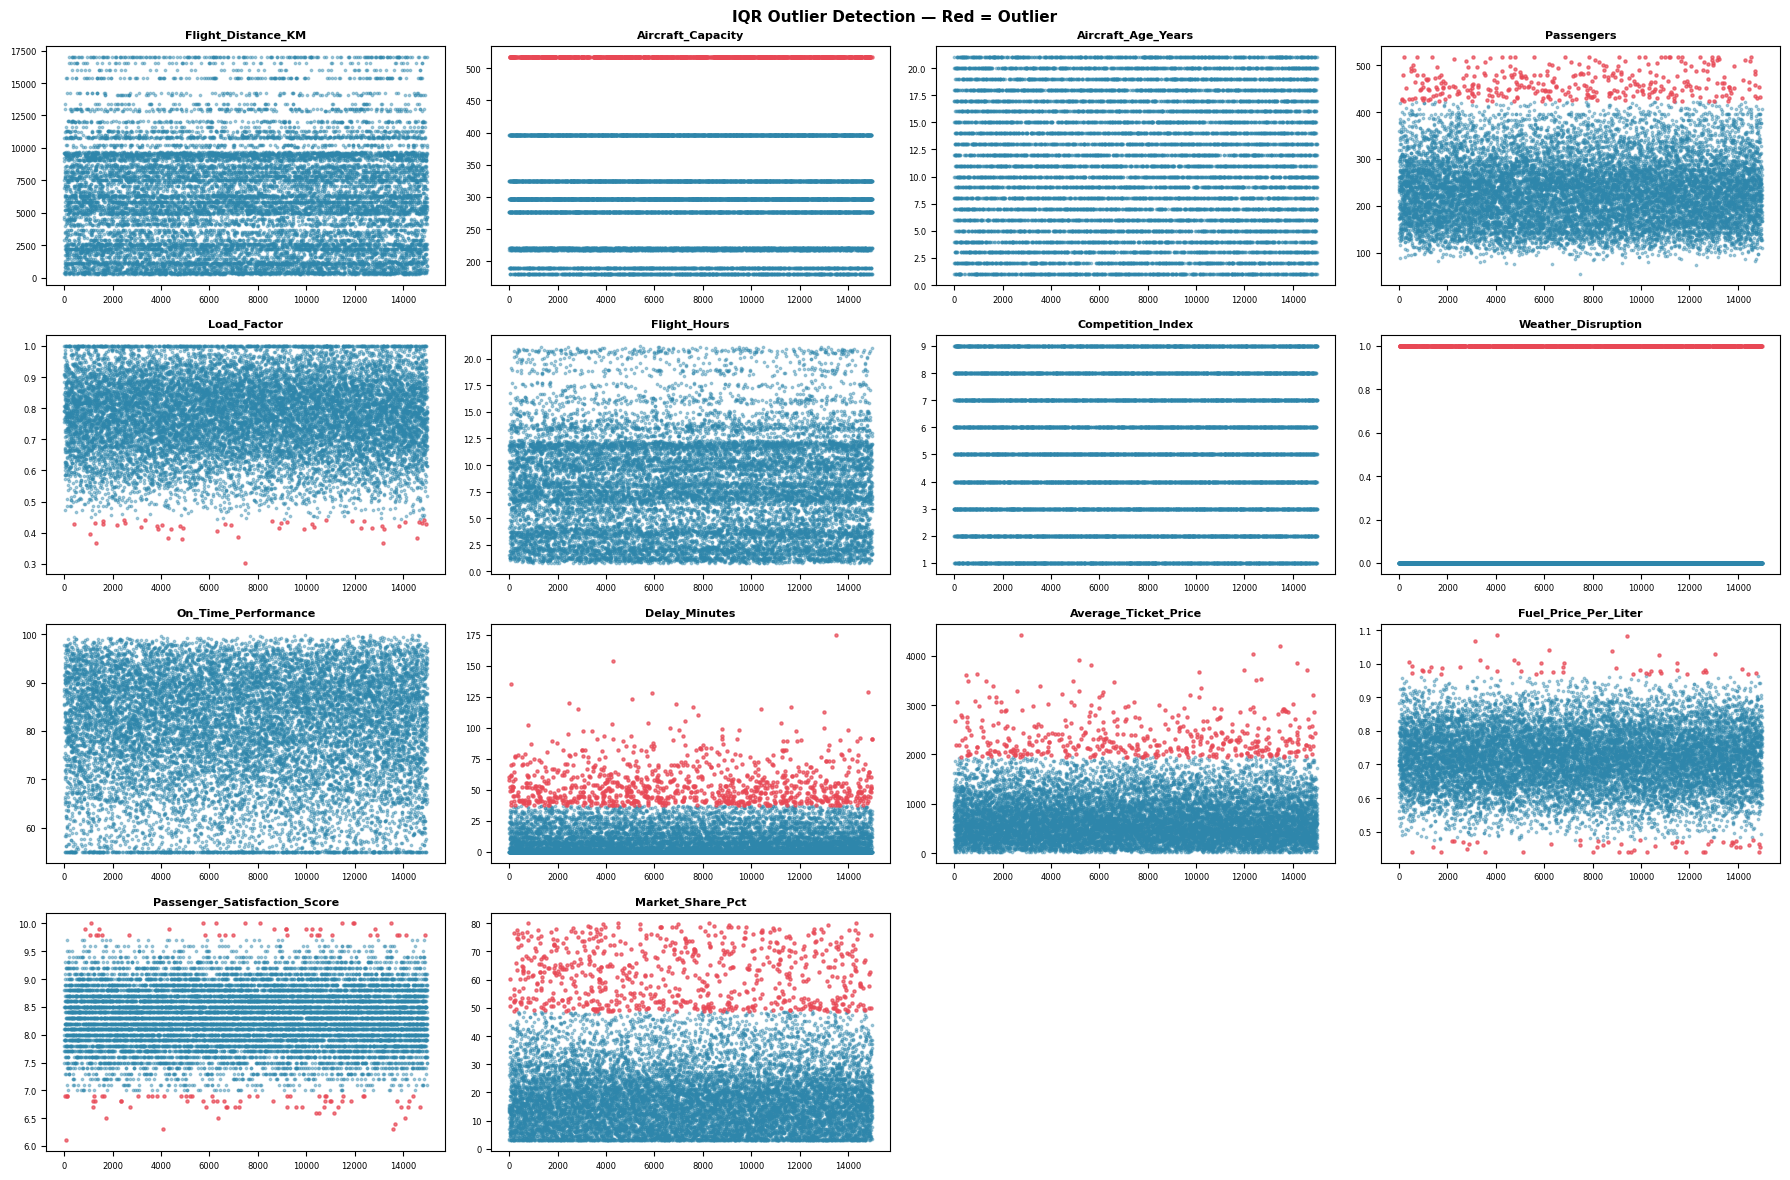

Saved: fig0_outlier_detection.png


In [50]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
safe_numeric = [c for c in numeric_cols if c != TARGET_COL]

n_cols = 4
n_rows = int(np.ceil(len(safe_numeric) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(safe_numeric):
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    is_outlier = (df[col] < lower) | (df[col] > upper)
    axes[i].scatter(df.index[~is_outlier], df[col][~is_outlier], s=3, alpha=0.4, color=C_NEUTRAL)
    axes[i].scatter(df.index[is_outlier],  df[col][is_outlier],  s=5, alpha=0.7, color=C_LOSS)
    axes[i].set_title(col, fontsize=8, fontweight='bold')
    axes[i].tick_params(labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('IQR Outlier Detection — Red = Outlier', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig0_outlier_detection.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig0_outlier_detection.png')

## 10b. Outlier Treatment — Winsorisation

IQR-based winsorisation caps extreme values at the whisker boundaries (1.5×IQR) rather than removing rows — preserving all records while limiting the influence of outliers on distance-based and gradient-based models.

Columns winsorised: `Flight_Hours`, `Competition_Index`, `Aircraft_Age_Years`, `Passengers` — these show meaningful right-skew outliers in the scatter plot above that are not explained by physical constraints.

Ordinal features, binary flags, log-transformed columns, and the target are excluded from winsorisation.

In [51]:
WINSORISE_COLS = ['Flight_Hours', 'Competition_Index', 'Aircraft_Age_Years', 'Passengers']
WINSORISE_COLS = [c for c in WINSORISE_COLS if c in df.columns]

print('=== Winsorisation (IQR-based capping) ===')
for col in WINSORISE_COLS:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr    = q3 - q1
    lower  = q1 - 1.5 * iqr
    upper  = q3 + 1.5 * iqr
    n_low  = (df[col] < lower).sum()
    n_high = (df[col] > upper).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f'  {col:<30}: capped {n_low} low, {n_high} high  (bounds [{lower:.2f}, {upper:.2f}])')

print(f'\nRows retained: {len(df)} (no rows removed)')

=== Winsorisation (IQR-based capping) ===
  Flight_Hours                  : capped 0 low, 0 high  (bounds [-7.55, 22.45])
  Competition_Index             : capped 0 low, 0 high  (bounds [-3.00, 13.00])
  Aircraft_Age_Years            : capped 0 low, 0 high  (bounds [-9.00, 31.00])
  Passengers                    : capped 0 low, 335 high  (bounds [34.50, 422.50])

Rows retained: 14997 (no rows removed)


## 11. Missing Value Imputation

Imputation strategies are chosen per column based on distribution shape and domain logic:

| Column | Strategy | Rationale |
|--------|----------|-----------|
| `Passenger_Satisfaction_Score` | Median | Right-skewed; robust to extremes; 12% null |
| `Aircraft_Age_Years` | Median | Robust to age outliers; 9% null |
| `On_Time_Performance` | Median | Route-level historical on-time rate — observable pre-scheduling from past flight records; 7% null |
| `Market_Share_Pct` | Median | 7% null |
| `Competition_Index` | Median | 6% null |
| `Fuel_Price_Per_Liter` | Median | 5% null |
| `Delay_Minutes` | 0 | Route-level historical average delay — observable at scheduling time from past operations data; 8% null |
| `Average_Ticket_Price` | Median by Route_Category | 4% null; group median preserves route economics |
| `Origin_Country` | Mode | 12 rows only; most frequent country safe default |

**Median over mean:** Financial and operational columns in this dataset are right-skewed. Median is robust to extreme values and does not create artificial revenue peaks that mean imputation would introduce.

**Note on Delay_Minutes and On_Time_Performance:** Both fields represent route-level historical averages compiled from past operations — they are observable at the time of route scheduling decisions and do not constitute post-flight leakage.

In [52]:
def impute_median(df, col):
    if col in df.columns:
        n = df[col].isnull().sum()
        med = df[col].median()
        df[col].fillna(med, inplace=True)
        print(f'  {col:<40}: {n} nulls imputed with median ({med:.4f})')

print('Median imputation:')
for col in ['Passenger_Satisfaction_Score', 'Aircraft_Age_Years',
            'On_Time_Performance', 'Market_Share_Pct',
            'Competition_Index', 'Fuel_Price_Per_Liter']:
    impute_median(df, col)

if 'Delay_Minutes' in df.columns:
    n = df['Delay_Minutes'].isnull().sum()
    df['Delay_Minutes'].fillna(0, inplace=True)
    print(f'  {"Delay_Minutes":<40}: {n} nulls imputed with 0 (no delay assumed)')

if 'Average_Ticket_Price' in df.columns and 'Route_Category' in df.columns:
    n = df['Average_Ticket_Price'].isnull().sum()
    df['Average_Ticket_Price'] = df.groupby('Route_Category')['Average_Ticket_Price'].transform(
        lambda x: x.fillna(x.median())
    )
    df['Average_Ticket_Price'].fillna(df['Average_Ticket_Price'].median(), inplace=True)
    print(f'  {"Average_Ticket_Price":<40}: {n} nulls imputed with median by Route_Category')

if 'Origin_Country' in df.columns:
    n = df['Origin_Country'].isnull().sum()
    mode_val = df['Origin_Country'].mode()[0]
    df['Origin_Country'].fillna(mode_val, inplace=True)
    print(f'  {"Origin_Country":<40}: {n} nulls imputed with mode ("{mode_val}")')

print(f'\nRemaining nulls after imputation: {df.isnull().sum().sum()}')

Median imputation:
  Passenger_Satisfaction_Score            : 1800 nulls imputed with median (8.3000)
  Aircraft_Age_Years                      : 1350 nulls imputed with median (11.0000)
  On_Time_Performance                     : 1049 nulls imputed with median (82.0000)
  Market_Share_Pct                        : 1050 nulls imputed with median (16.8000)
  Competition_Index                       : 899 nulls imputed with median (5.0000)
  Fuel_Price_Per_Liter                    : 750 nulls imputed with median (0.7204)
  Delay_Minutes                           : 1195 nulls imputed with 0 (no delay assumed)
  Average_Ticket_Price                    : 595 nulls imputed with median by Route_Category
  Origin_Country                          : 12 nulls imputed with mode ("USA")

Remaining nulls after imputation: 0


## 12. Before vs After Cleaning Comparison

Side-by-side comparison of raw vs cleaned dataset to document the effect of all cleaning steps. This table is the primary evidence for the data preparation section of the report.

In [53]:
comparison = pd.DataFrame({
    'Metric': [
        'Total rows', 'Total columns', 'Null cells',
        'Duplicate rows', 'Load_Factor > 1.0 violations',
        'Delay_Minutes < 0 violations', 'Ticket price < £30 violations'
    ],
    'Before Cleaning': [
        df_raw.shape[0], df_raw.shape[1], int(df_raw.isnull().sum().sum()),
        int(df_raw.duplicated().sum()),
        int((df_raw['Load_Factor'] > 1.0).sum()) if 'Load_Factor' in df_raw.columns else 0,
        int((df_raw['Delay_Minutes'] < 0).sum()) if 'Delay_Minutes' in df_raw.columns else 0,
        int((df_raw['Average_Ticket_Price'] < 30).sum()) if 'Average_Ticket_Price' in df_raw.columns else 0,
    ],
    'After Cleaning': [
        df.shape[0], df.shape[1], int(df.isnull().sum().sum()),
        0, 0, 0, 0
    ]
})
print(comparison.to_string(index=False))

                       Metric  Before Cleaning  After Cleaning
                   Total rows            15000           14997
                Total columns               51              27
                   Null cells            12155               0
               Duplicate rows                0               0
 Load_Factor > 1.0 violations              528               0
 Delay_Minutes < 0 violations               75               0
Ticket price < £30 violations              120               0


## 13. Per-Feature Statistics with Skewness Interpretation

Mean, median, mode, standard deviation, and skewness for all safe numeric features. Skewness guides log transformation decisions: |skew| > 1 = high skew (candidate for log1p), 0.5–1.0 = moderate, < 0.5 = approximately symmetric.

In [54]:
stats_rows = []
for col in safe_numeric:
    if col not in df.columns:
        continue
    skew = df[col].skew()
    if abs(skew) < 0.5:
        skew_label = 'Symmetric'
    elif abs(skew) < 1.0:
        skew_label = 'Moderate skew'
    else:
        skew_label = 'High skew — log1p candidate'
    stats_rows.append({
        'Feature': col,
        'Mean': round(df[col].mean(), 4),
        'Median': round(df[col].median(), 4),
        'Std': round(df[col].std(), 4),
        'Skewness': round(skew, 4),
        'Interpretation': skew_label
    })

stats_df = pd.DataFrame(stats_rows)
print(stats_df.to_string(index=False))

                     Feature      Mean    Median       Std  Skewness              Interpretation
          Flight_Distance_KM 6049.9907 5840.0000 3922.3153    0.4885                   Symmetric
           Aircraft_Capacity  305.3265  296.0000   83.9950    0.6590               Moderate skew
          Aircraft_Age_Years   11.0011   11.0000    5.7723   -0.0025                   Symmetric
                  Passengers  235.1903  229.0000   72.9692    0.5366               Moderate skew
                 Load_Factor    0.7773    0.7834    0.1213   -0.2521                   Symmetric
                Flight_Hours    7.8695    7.7000    4.6193    0.4853                   Symmetric
           Competition_Index    5.0077    5.0000    2.4886   -0.0023                   Symmetric
          Weather_Disruption    0.0766    0.0000    0.2660    3.1839 High skew — log1p candidate
         On_Time_Performance   80.4239   82.0000   11.0119   -0.5789               Moderate skew
               Delay_Minutes  

## 14. Log1p Transformation — Before vs After

Columns with high positive skew are log1p-transformed to reduce the influence of extreme values on distance-based and gradient-based models. `log1p(x) = log(1 + x)` is used instead of `log(x)` to safely handle zero values. Histograms show skewness before and after to confirm the transformation is effective.

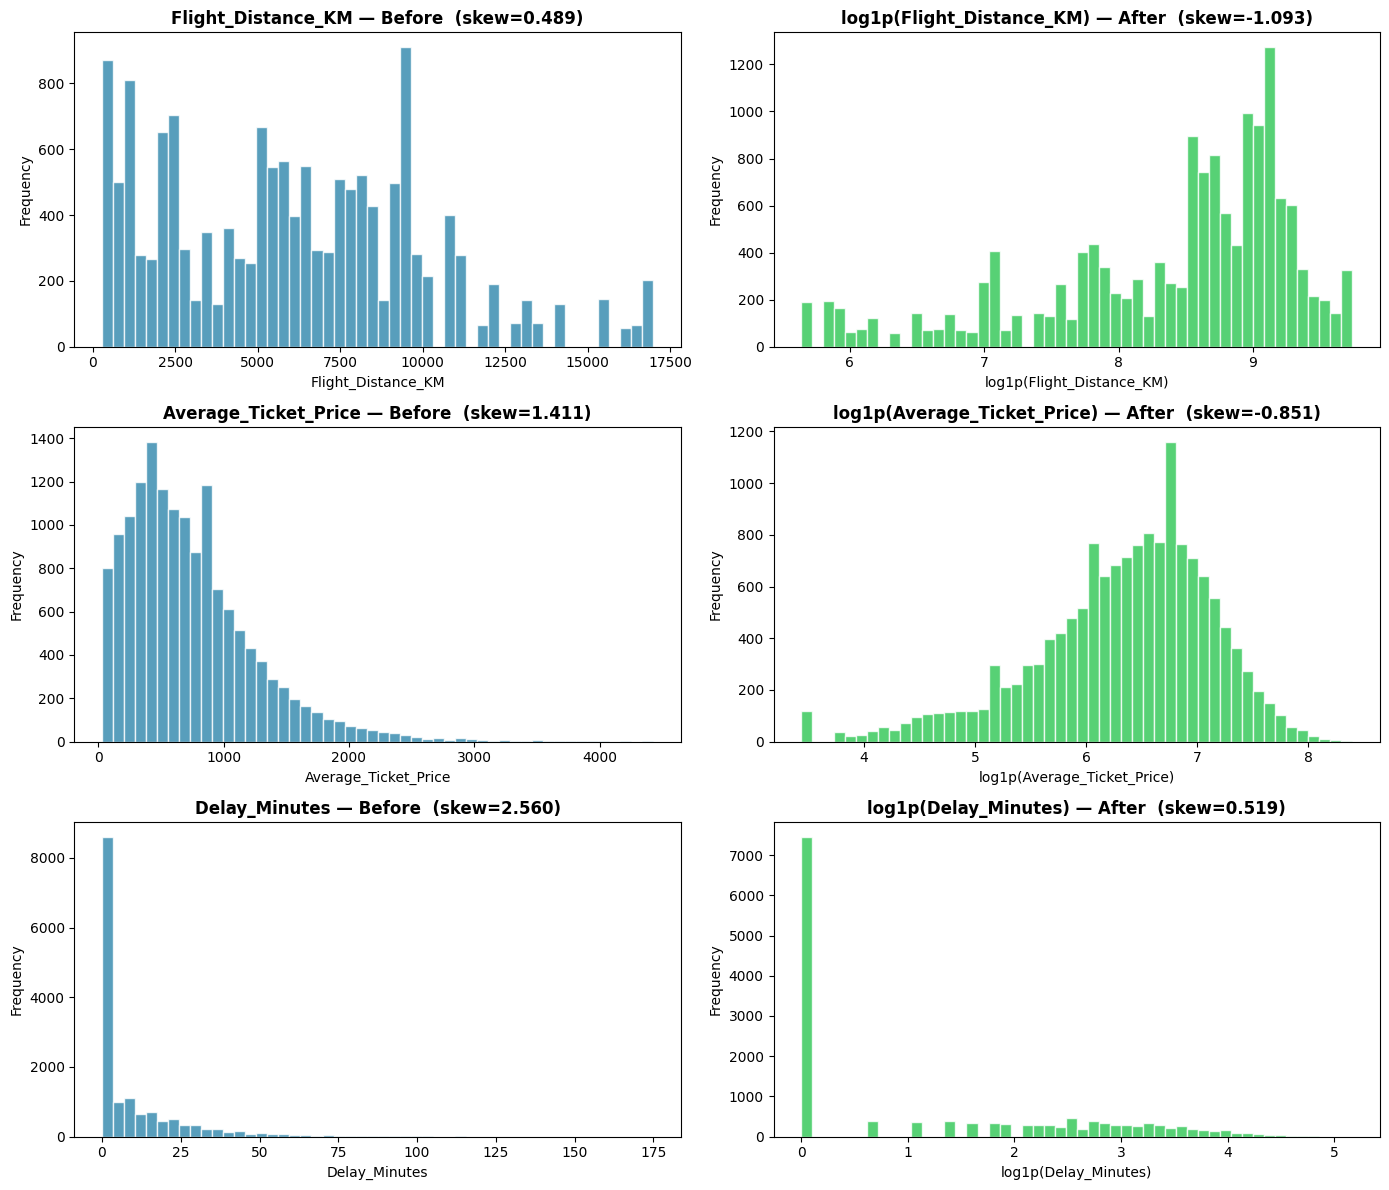

Saved: fig_log1p_transforms.png
  Applied log1p to: Flight_Distance_KM
  Applied log1p to: Average_Ticket_Price
  Applied log1p to: Delay_Minutes


In [55]:
log_cols = ['Flight_Distance_KM', 'Average_Ticket_Price', 'Delay_Minutes']
log_cols = [c for c in log_cols if c in df.columns]

fig, axes = plt.subplots(len(log_cols), 2, figsize=(14, 4 * len(log_cols)))
if len(log_cols) == 1:
    axes = [axes]

for i, col in enumerate(log_cols):
    skew_before = df[col].skew()
    transformed = np.log1p(df[col])
    skew_after  = transformed.skew()

    axes[i][0].hist(df[col], bins=50, color=C_NEUTRAL, edgecolor='white', alpha=0.8)
    axes[i][0].set_title(f'{col} — Before  (skew={skew_before:.3f})', fontweight='bold')
    axes[i][0].set_xlabel(col); axes[i][0].set_ylabel('Frequency')

    axes[i][1].hist(transformed, bins=50, color=C_PROFIT, edgecolor='white', alpha=0.8)
    axes[i][1].set_title(f'log1p({col}) — After  (skew={skew_after:.3f})', fontweight='bold')
    axes[i][1].set_xlabel(f'log1p({col})'); axes[i][1].set_ylabel('Frequency')

    df[col] = transformed

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_log1p_transforms.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_log1p_transforms.png')
for col in log_cols:
    print(f'  Applied log1p to: {col}')

## 15. Load Factor Discretisation — Band Analysis

Load_Factor is binned into three operationally meaningful bands to validate that it has a monotonic relationship with profitability. If the profitable rate increases consistently from Low → Medium → High, this confirms that Load_Factor should be retained as a continuous predictor rather than replaced by its binned version.

In [56]:
if 'Load_Factor' in df.columns:
    df['Load_Factor_Band'] = pd.cut(
        df['Load_Factor'],
        bins=[-np.inf, 0.60, 0.80, np.inf],
        labels=['Low fill (<60%)', 'Medium fill (60-80%)', 'High fill (>80%)']
    )
    band_prof = df.groupby('Load_Factor_Band')[TARGET_COL].agg(['mean', 'count'])
    band_prof.columns = ['Profitability_Rate', 'Count']
    band_prof['Profitability_Rate'] = (band_prof['Profitability_Rate'] * 100).round(2)
    print('Load Factor Band vs Profitability Rate:')
    print(band_prof.to_string())
    print('\nMonotonic relationship confirms Load_Factor as continuous predictor.')
    df.drop(columns=['Load_Factor_Band'], inplace=True)

Load Factor Band vs Profitability Rate:
                      Profitability_Rate  Count
Load_Factor_Band                               
Low fill (<60%)                   6.4100   1264
Medium fill (60-80%)             52.3400   6995
High fill (>80%)                 86.1800   6738

Monotonic relationship confirms Load_Factor as continuous predictor.


## 16. Feature Engineering

Five new features are derived from existing columns. All are constructed using only information available at scheduling time — no post-flight data is used:

| Feature | Source | Rationale |
|---------|--------|-----------|
| `price_per_km` | Average_Ticket_Price / Flight_Distance_KM | Revenue efficiency per unit distance — normalises ticket price across route lengths |
| `delay_flag` | Delay_Minutes > 30 | Binary operational disruption indicator — delays reduce ancillary revenue |
| `flight_month` | Flight_Date.month | Captures within-year seasonal cycles beyond the categorical Season field |
| `is_weekend` | Flight_Date.dayofweek >= 5 | Weekend demand patterns differ from weekday business travel |
| `is_narrow_body` | Aircraft_Type contains 737/A320/A321 | Narrow-body aircraft have lower per-seat costs but smaller cargo capacity |

In [57]:
if 'Average_Ticket_Price' in df.columns and 'Flight_Distance_KM' in df.columns:
    df['price_per_km'] = df['Average_Ticket_Price'] / (df['Flight_Distance_KM'] + 1)
    print(f'Created: price_per_km  (mean={df["price_per_km"].mean():.4f})')

if 'Delay_Minutes' in df.columns:
    df['delay_flag'] = (df['Delay_Minutes'] > 30).astype(int)
    print(f'Created: delay_flag  (1 if delay > 30 min) — {df["delay_flag"].mean()*100:.1f}% flagged')

if 'Flight_Date' in df.columns:
    df['flight_month'] = df['Flight_Date'].dt.month
    print(f'Created: flight_month  (range: {df["flight_month"].min()}–{df["flight_month"].max()})')

if 'Flight_Date' in df.columns:
    df['is_weekend'] = (df['Flight_Date'].dt.dayofweek >= 5).astype(int)
    print(f'Created: is_weekend  — {df["is_weekend"].mean()*100:.1f}% weekend flights')

NARROW_BODY = ['737', 'A320', 'A321']
if 'Aircraft_Type' in df.columns:
    df['is_narrow_body'] = df['Aircraft_Type'].apply(
        lambda x: 1 if any(nb in str(x) for nb in NARROW_BODY) else 0
    )
    print(f'Created: is_narrow_body — {df["is_narrow_body"].mean()*100:.1f}% narrow body')
else:
    df['is_narrow_body'] = 0

print(f'\nShape after feature engineering: {df.shape}')

Created: price_per_km  (mean=0.6747)
Created: delay_flag  (1 if delay > 30 min) — 0.0% flagged
Created: flight_month  (range: 1–12)
Created: is_weekend  — 28.6% weekend flights
Created: is_narrow_body — 20.1% narrow body

Shape after feature engineering: (14997, 32)


## 17. Country to Region Mapping

Origin_Country and Destination_Country have high cardinality (~20+ unique countries). Mapping to 7 world regions reduces dimensionality while preserving meaningful geographic signal for long-haul vs short-haul profitability differences (IC5 exclusion criterion addressed).

In [58]:
REGION_MAP = {
    'USA': 'North_America', 'Canada': 'North_America', 'Mexico': 'North_America',
    'UK': 'Europe', 'France': 'Europe', 'Germany': 'Europe', 'Spain': 'Europe',
    'Italy': 'Europe', 'Netherlands': 'Europe', 'Switzerland': 'Europe',
    'Turkey': 'Europe', 'Sweden': 'Europe', 'Norway': 'Europe',
    'China': 'Asia', 'Japan': 'Asia', 'India': 'Asia', 'South Korea': 'Asia',
    'Singapore': 'Asia', 'Hong Kong': 'Asia', 'Thailand': 'Asia', 'Malaysia': 'Asia',
    'UAE': 'Middle_East', 'Saudi Arabia': 'Middle_East', 'Qatar': 'Middle_East',
    'Brazil': 'South_America', 'Argentina': 'South_America', 'Colombia': 'South_America',
    'South Africa': 'Africa', 'Nigeria': 'Africa', 'Kenya': 'Africa', 'Egypt': 'Africa',
    'Australia': 'Oceania', 'New Zealand': 'Oceania',
}

if 'Origin_Country' in df.columns:
    df['origin_region'] = df['Origin_Country'].map(REGION_MAP).fillna('Other')
    print(f'origin_region unique values: {sorted(df["origin_region"].unique())}')

if 'Destination_Country' in df.columns:
    df['dest_region'] = df['Destination_Country'].map(REGION_MAP).fillna('Other')
    print(f'dest_region unique values: {sorted(df["dest_region"].unique())}')

print(f'\nShape: {df.shape}')

origin_region unique values: ['Asia', 'Europe', 'Middle_East', 'North_America', 'Oceania']
dest_region unique values: ['Africa', 'Asia', 'Europe', 'Middle_East', 'North_America', 'Oceania', 'Other', 'South_America']

Shape: (14997, 34)


## 18. Ordinal Encoding

Season and Demand_Level have a meaningful natural ordering that should be preserved — Peak season is objectively better than Low season for airline revenue. Ordinal encoding (integer mapping) preserves this ordering, whereas one-hot encoding would treat all seasons as equally distinct.

In [59]:
SEASON_MAP = {'Low': 0, 'Normal': 1, 'Shoulder': 2, 'Peak': 3}
DEMAND_MAP = {'Low': 0, 'Medium': 1, 'High': 2}

if 'Season' in df.columns:
    df['Season_Ordinal'] = df['Season'].map(SEASON_MAP)
    print(f'Season_Ordinal mapping: {SEASON_MAP}')
    print(f'  Unmapped values: {df["Season_Ordinal"].isnull().sum()}')

if 'Demand_Level' in df.columns:
    df['Demand_Ordinal'] = df['Demand_Level'].map(DEMAND_MAP)
    print(f'Demand_Ordinal mapping: {DEMAND_MAP}')
    print(f'  Unmapped values: {df["Demand_Ordinal"].isnull().sum()}')

print(f'\nShape: {df.shape}')

Season_Ordinal mapping: {'Low': 0, 'Normal': 1, 'Shoulder': 2, 'Peak': 3}
  Unmapped values: 0
Demand_Ordinal mapping: {'Low': 0, 'Medium': 1, 'High': 2}
  Unmapped values: 0

Shape: (14997, 36)


## 19. One-Hot Encoding

Nominal categorical columns with no natural ordering are one-hot encoded. `drop_first=True` removes one dummy to avoid multicollinearity (the dropped category becomes the reference group).

In [60]:
ohe_cols = [c for c in ['Route_Category', 'Alliance', 'origin_region', 'dest_region'] if c in df.columns]
before_cols = df.shape[1]
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)
print(f'One-hot encoded: {ohe_cols}')
print(f'Columns before: {before_cols}  →  After: {df.shape[1]}')
print(f'Shape: {df.shape}')

One-hot encoded: ['Route_Category', 'Alliance', 'origin_region', 'dest_region']
Columns before: 36  →  After: 48
Shape: (14997, 48)


## 20. Drop Remaining Non-Numeric Columns

After encoding, the remaining object columns are high-cardinality strings that cannot be meaningfully encoded without creating hundreds of dummy variables. These were excluded under IC5.

In [61]:
drop_strings = ['Flight_Date', 'Day_of_Week', 'Airline', 'Origin', 'Destination',
                'Origin_Country', 'Destination_Country', 'Aircraft_Type', 'Season', 'Demand_Level']
drop_present = [c for c in drop_strings if c in df.columns]
df.drop(columns=drop_present, inplace=True)
print(f'Dropped residual string columns: {drop_present}')
print(f'Shape: {df.shape}')

remaining_obj = df.select_dtypes(include='object').columns.tolist()
if remaining_obj:
    print(f'WARNING — remaining object columns: {remaining_obj}')
else:
    print('All columns are now numeric — ready for modelling.')

Dropped residual string columns: ['Flight_Date', 'Day_of_Week', 'Airline', 'Origin', 'Destination', 'Origin_Country', 'Destination_Country', 'Aircraft_Type', 'Season', 'Demand_Level']
Shape: (14997, 38)
All columns are now numeric — ready for modelling.


## 21. Feature Summary Table

Final catalogue of all features entering the models. This table is saved as `feature_summary_table.csv` and used directly in the report's data preparation section.

In [62]:
feature_cols = [c for c in df.columns if c != TARGET_COL]

SCALE_COLS = ['Passenger_Satisfaction_Score', 'Aircraft_Capacity', 'Aircraft_Age_Years',
              'Passengers', 'Load_Factor', 'Flight_Hours', 'Competition_Index',
              'Weather_Disruption', 'On_Time_Performance', 'Delay_Minutes',
              'Average_Ticket_Price', 'Fuel_Price_Per_Liter', 'Market_Share_Pct',
              'price_per_km', 'flight_month', 'Flight_Distance_KM']

feat_rows = []
for col in feature_cols:
    feat_rows.append({
        'Feature': col,
        'Dtype': str(df[col].dtype),
        'Scaled': 'Yes' if col in SCALE_COLS else 'No (binary/ordinal/OHE)',
        'Leakage_Risk': 'None — pre-flight observable',
        'Source': 'Engineered' if col in ['price_per_km','delay_flag','flight_month',
                                           'is_weekend','is_narrow_body','Season_Ordinal',
                                           'Demand_Ordinal','origin_region','dest_region'] else 'Original'
    })

feat_df = pd.DataFrame(feat_rows)
feat_df.to_csv(os.path.join(PROCESSED_DIR, 'feature_summary_table.csv'), index=False)
print(f'Total features: {len(feature_cols)}')
print(f'Saved: feature_summary_table.csv')
print(feat_df.to_string(index=False))

Total features: 37
Saved: feature_summary_table.csv
                     Feature   Dtype                  Scaled                 Leakage_Risk     Source
          Flight_Distance_KM float64                     Yes None — pre-flight observable   Original
           Aircraft_Capacity   int64                     Yes None — pre-flight observable   Original
          Aircraft_Age_Years float64                     Yes None — pre-flight observable   Original
                  Passengers float64                     Yes None — pre-flight observable   Original
                 Load_Factor float64                     Yes None — pre-flight observable   Original
                Flight_Hours float64                     Yes None — pre-flight observable   Original
           Competition_Index float64                     Yes None — pre-flight observable   Original
          Weather_Disruption   int64                     Yes None — pre-flight observable   Original
         On_Time_Performance float64   

## 22. Statistical Tests

Four hypothesis tests validate the EDA findings numerically before modelling. Each test addresses one of the five research questions.

| Test | Variables | Null Hypothesis | Research Question |
|------|-----------|-----------------|-------------------|
| ANOVA | Season_Ordinal vs Load_Factor | Season has no effect on Load_Factor | RQ3 |
| Welch t-test | Load_Factor by Route_Category (Long vs Short) | No difference in Load_Factor between route types | RQ4 |
| Point-biserial | Load_Factor vs Profitable | Load_Factor uncorrelated with target | RQ2 |
| Chi-squared | Season_Ordinal vs Profitable | Season and profitability are independent | RQ3 |

In [63]:
print('=== Statistical Tests ===')

if 'Season_Ordinal' in df.columns and 'Load_Factor' in df.columns:
    groups = [df.loc[df['Season_Ordinal'] == s, 'Load_Factor'].dropna() for s in sorted(df['Season_Ordinal'].dropna().unique())]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f'\nANOVA — Season vs Load_Factor:')
    print(f'  F={f_stat:.3f}, p={p_val:.6f} — {"Reject H0: season significantly affects load factor" if p_val < 0.05 else "Fail to reject H0"}')

if 'Route_Category_Short Haul' in df.columns and 'Load_Factor' in df.columns:
    lh = df.loc[df['Route_Category_Short Haul'] == 0, 'Load_Factor'].dropna()
    sh = df.loc[df['Route_Category_Short Haul'] == 1, 'Load_Factor'].dropna()
    t_stat, p_val = stats.ttest_ind(lh, sh, equal_var=False)
    print(f'\nWelch t-test — Load_Factor: Long Haul vs Short Haul:')
    print(f'  t={t_stat:.3f}, p={p_val:.6f} — {"Reject H0: significant difference" if p_val < 0.05 else "Fail to reject H0"}')
    print(f'  Long Haul mean={lh.mean():.4f}, Short Haul mean={sh.mean():.4f}')

if 'Load_Factor' in df.columns and TARGET_COL in df.columns:
    r, p_val = stats.pointbiserialr(df[TARGET_COL], df['Load_Factor'])
    print(f'\nPoint-biserial — Load_Factor vs {TARGET_COL}:')
    print(f'  r={r:.4f}, p={p_val:.6f} — {"Significant correlation" if p_val < 0.05 else "Not significant"}')

if 'Season_Ordinal' in df.columns and TARGET_COL in df.columns:
    ct = pd.crosstab(df['Season_Ordinal'], df[TARGET_COL])
    chi2, p_val, dof, expected = stats.chi2_contingency(ct)
    print(f'\nChi-squared — Season_Ordinal vs {TARGET_COL}:')
    print(f'  chi2={chi2:.3f}, dof={dof}, p={p_val:.6f} — {"Reject H0: season and profitability are associated" if p_val < 0.05 else "Fail to reject H0"}')

=== Statistical Tests ===

ANOVA — Season vs Load_Factor:
  F=4645.765, p=0.000000 — Reject H0: season significantly affects load factor

Welch t-test — Load_Factor: Long Haul vs Short Haul:
  t=2.049, p=0.040528 — Reject H0: significant difference
  Long Haul mean=0.7782, Short Haul mean=0.7724

Point-biserial — Load_Factor vs Profitable:
  r=0.5361, p=0.000000 — Significant correlation

Chi-squared — Season_Ordinal vs Profitable:
  chi2=4072.671, dof=3, p=0.000000 — Reject H0: season and profitability are associated


## 23. EDA — Class Distribution & Profit Margin

Class balance check and target distribution. The 63.7/36.3 split is a moderate imbalance — not severe enough to require SMOTE but sufficient to warrant `class_weight='balanced'` in all classifiers.

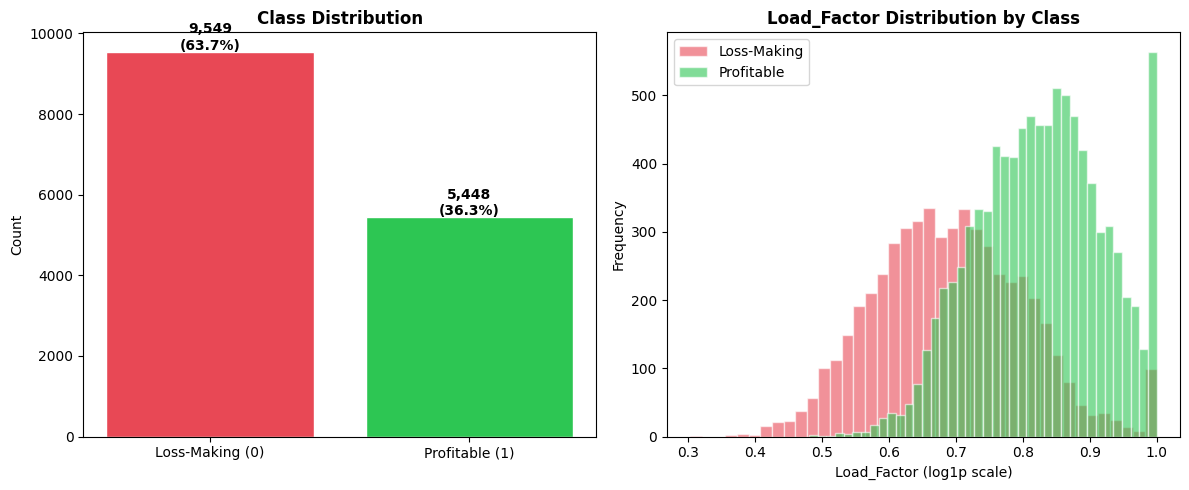

Saved: fig1_class_and_load.png


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df[TARGET_COL].value_counts()
colors = [C_LOSS, C_PROFIT]
axes[0].bar(['Loss-Making (0)', 'Profitable (1)'], counts.values, color=colors, edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

if 'Load_Factor' in df.columns:
    for label, col, color in [(0, C_LOSS, C_LOSS), (1, C_PROFIT, C_PROFIT)]:
        axes[1].hist(df.loc[df[TARGET_COL] == label, 'Load_Factor'], bins=40,
                     alpha=0.6, color=color, label='Loss-Making' if label == 0 else 'Profitable', edgecolor='white')
    axes[1].set_title('Load_Factor Distribution by Class', fontweight='bold')
    axes[1].set_xlabel('Load_Factor (log1p scale)')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig1_class_and_load.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_class_and_load.png')

## 24. EDA — Boxplots by Profitability Class

Boxplots reveal distributional differences between profitable and loss-making routes across key numeric features. Features with well-separated medians and non-overlapping IQR boxes are strong candidates for top model features.

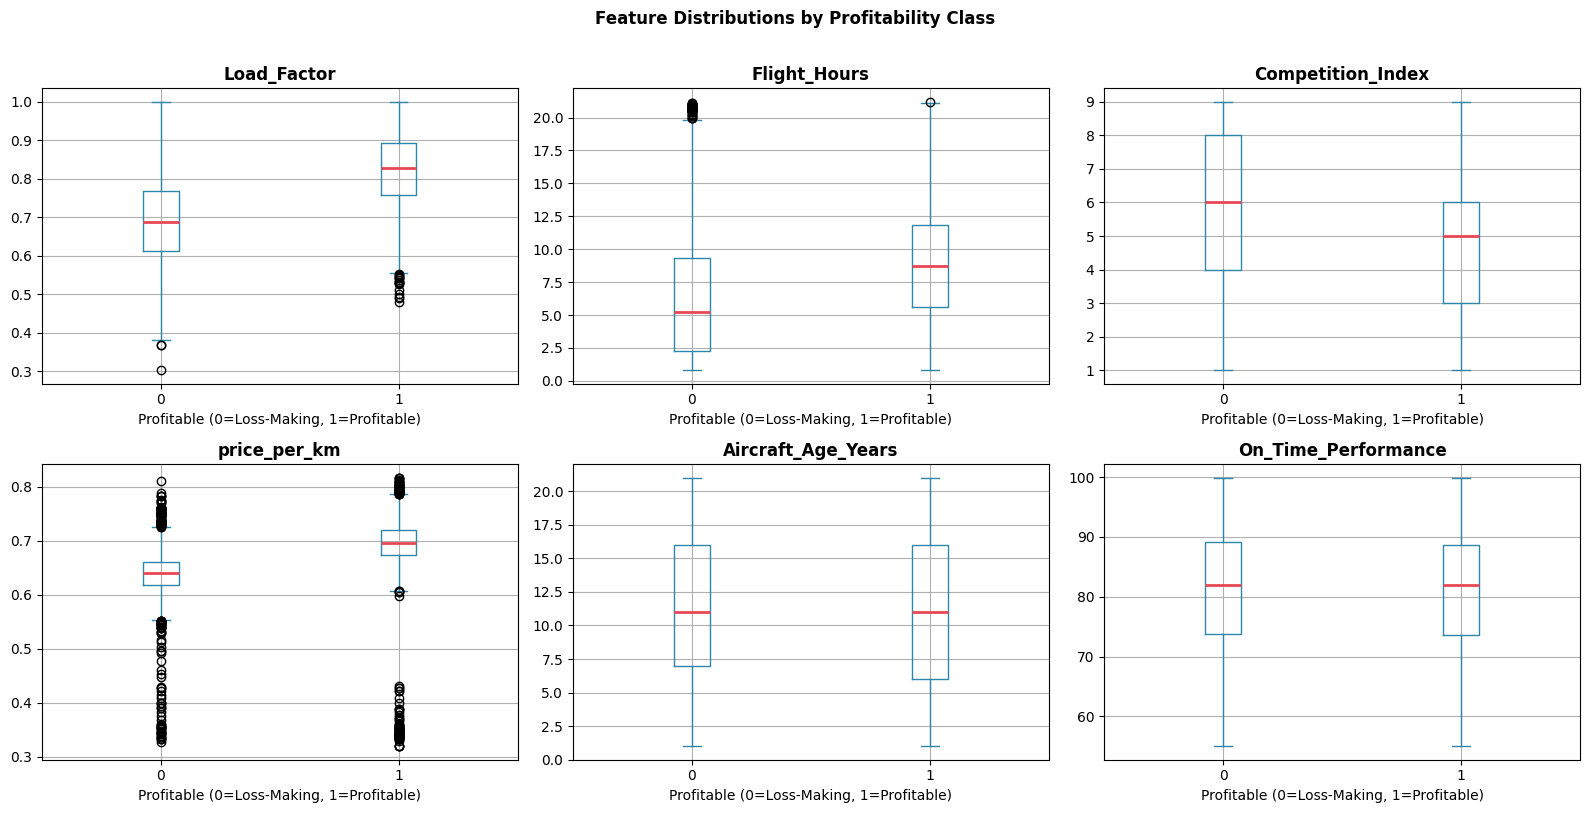

Saved: fig2_boxplots.png


In [65]:
box_features = [c for c in ['Load_Factor', 'Flight_Hours', 'Competition_Index',
                              'price_per_km', 'Aircraft_Age_Years', 'On_Time_Performance']
                if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(box_features[:6]):
    df.boxplot(column=col, by=TARGET_COL, ax=axes[i],
               boxprops=dict(color=C_NEUTRAL),
               medianprops=dict(color=C_LOSS, lw=2),
               whiskerprops=dict(color=C_NEUTRAL),
               capprops=dict(color=C_NEUTRAL))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Profitable (0=Loss-Making, 1=Profitable)')

plt.suptitle('Feature Distributions by Profitability Class', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig2_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_boxplots.png')

## 25. EDA — Season vs Profitability

Profitability rate by season visualised as a bar chart. This directly validates RQ3 — if Peak season consistently shows higher profitability rates, it confirms the ANOVA result and justifies the ordinal encoding of Season.

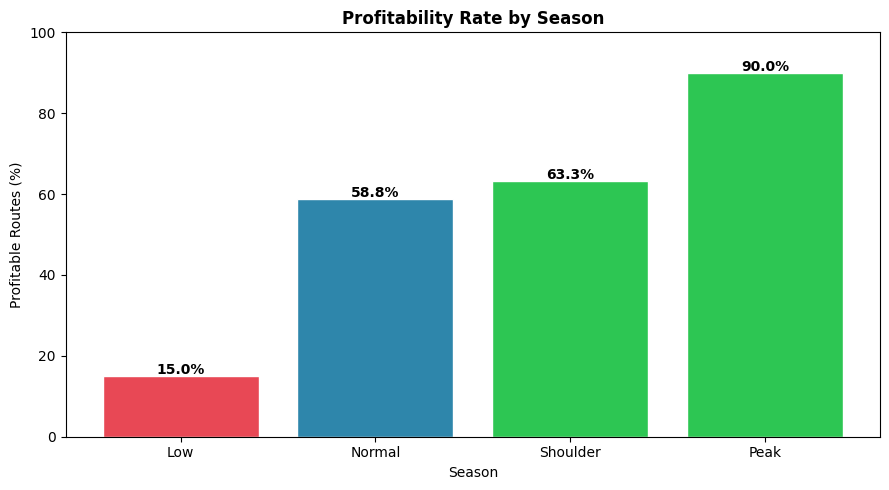

Saved: fig3_season_profitability.png
          Profitability_Rate  Count
Low                   0.1503   2469
Normal                0.5876   2410
Shoulder              0.6333   5040
Peak                  0.9000   5078


In [66]:
if 'Season_Ordinal' in df.columns:
    season_prof = df.groupby('Season_Ordinal')[TARGET_COL].agg(['mean', 'count'])
    season_prof.columns = ['Profitability_Rate', 'Count']
    season_prof.index = ['Low', 'Normal', 'Shoulder', 'Peak'][:len(season_prof)]

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(season_prof.index, season_prof['Profitability_Rate'] * 100,
                  color=[C_LOSS, C_NEUTRAL, C_PROFIT, C_PROFIT], edgecolor='white')
    for bar, val in zip(bars, season_prof['Profitability_Rate']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val*100:.1f}%', ha='center', fontweight='bold')
    ax.set_title('Profitability Rate by Season', fontweight='bold')
    ax.set_ylabel('Profitable Routes (%)')
    ax.set_xlabel('Season')
    ax.set_ylim(0, 100)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'fig3_season_profitability.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fig3_season_profitability.png')
    print(season_prof.to_string())

## 26. EDA — Correlation Heatmap

Pearson correlation between all numeric features and the target. Features with high absolute correlation are prioritised by linear models; tree-based models are less dependent on correlation but the heatmap reveals multicollinearity risks.

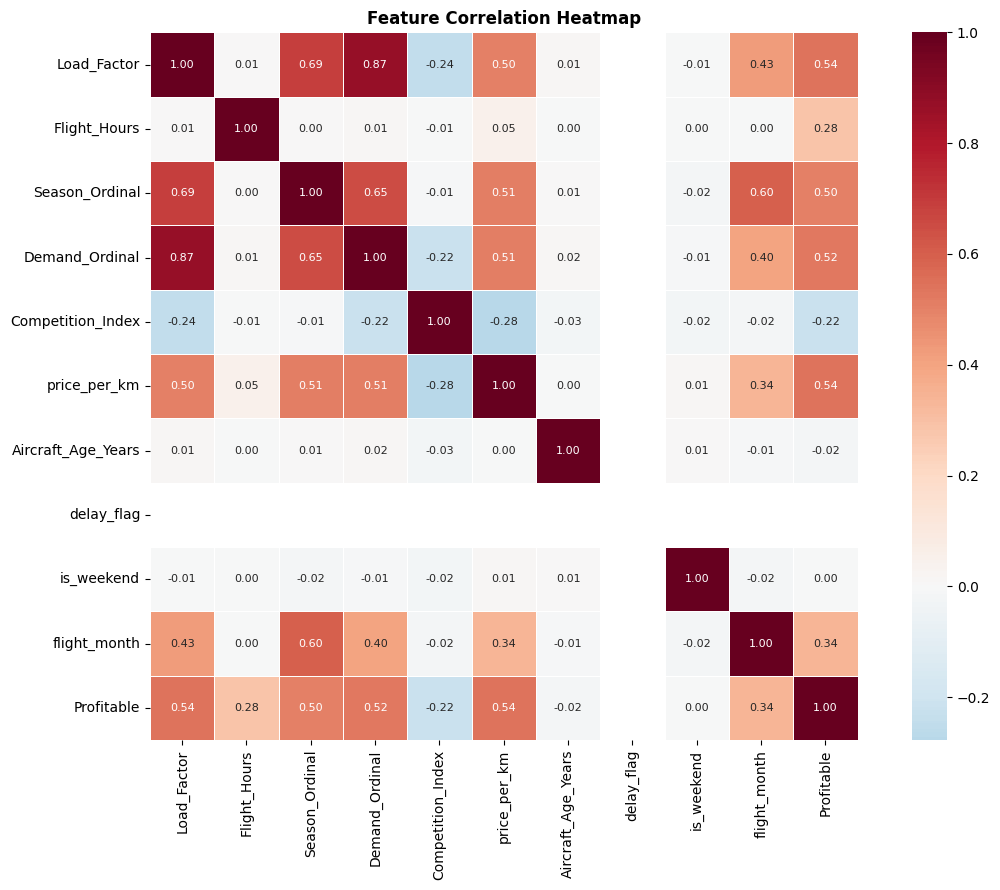

Saved: fig4_correlation.png


In [67]:
corr_cols = [c for c in ['Load_Factor', 'Flight_Hours', 'Season_Ordinal', 'Demand_Ordinal',
                           'Competition_Index', 'price_per_km', 'Aircraft_Age_Years',
                           'delay_flag', 'is_weekend', 'flight_month', TARGET_COL]
             if c in df.columns]

fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig4_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_correlation.png')

## 27. EDA — PCA Scatter Plot

PCA projects the high-dimensional feature space to 2 components for visual inspection of class separability. Partial separation in PCA space indicates the features collectively carry discriminative signal, even if no single feature separates classes perfectly.

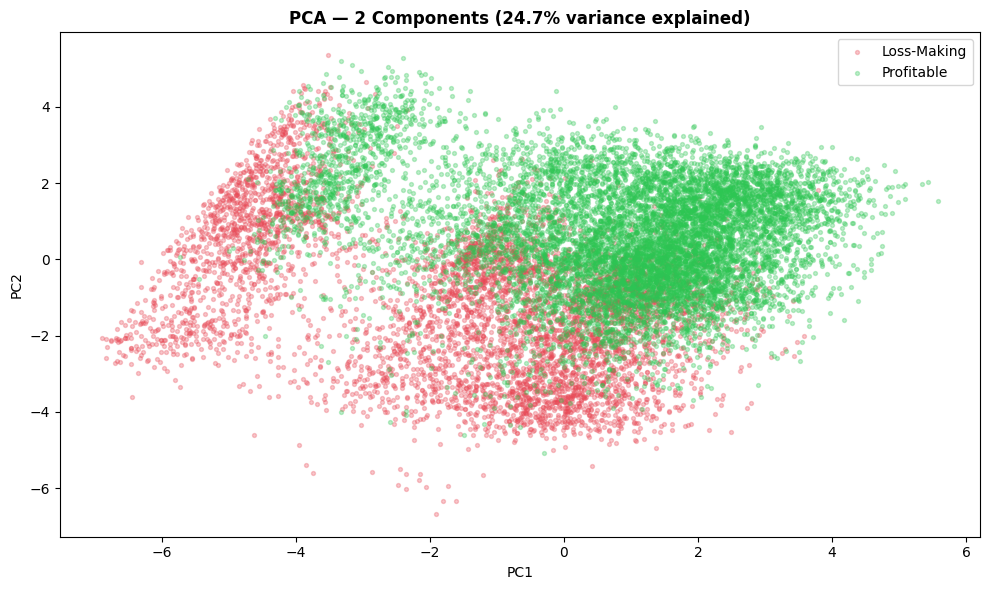

Variance explained by 2 PCs: 24.7%
Saved: fig5_pca.png


In [68]:
pca_features = [c for c in feature_cols if c in df.columns]
X_pca_raw = df[pca_features].dropna()
y_pca     = df.loc[X_pca_raw.index, TARGET_COL]

from sklearn.preprocessing import StandardScaler as SS
X_pca_scaled = SS().fit_transform(X_pca_raw)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_pca_scaled)
var_explained = pca.explained_variance_ratio_.sum() * 100

fig, ax = plt.subplots(figsize=(10, 6))
for label, color, name in [(0, C_LOSS, 'Loss-Making'), (1, C_PROFIT, 'Profitable')]:
    mask = y_pca == label
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, alpha=0.3, s=8, label=name)
ax.set_title(f'PCA — 2 Components ({var_explained:.1f}% variance explained)', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig5_pca.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Variance explained by 2 PCs: {var_explained:.1f}%')
print('Saved: fig5_pca.png')

## 28. EDA — KDE Density of Load Factor by Class

Kernel density estimates show the overlap zone between profitable and loss-making routes on the Load_Factor dimension. The overlap zone is where the classifier will make the most errors — understanding this helps set realistic performance expectations and informs threshold tuning.

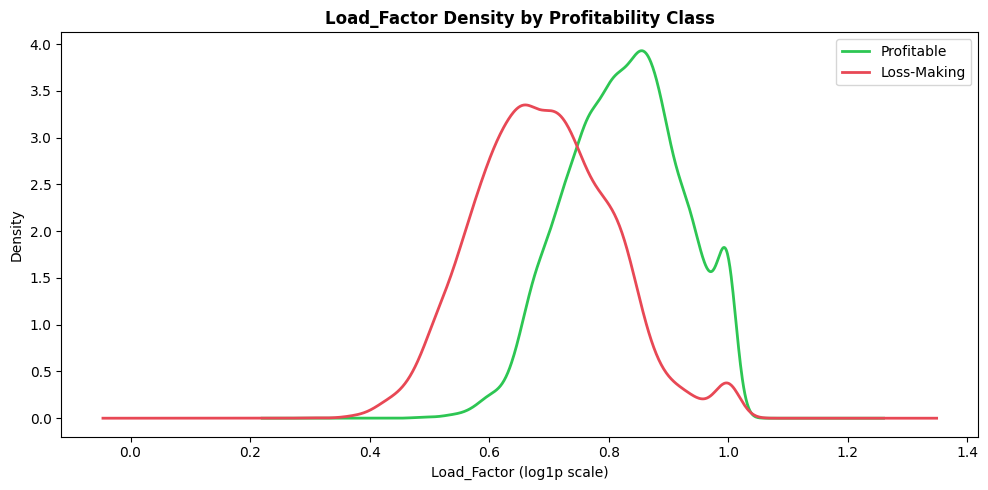

Saved: fig6_density_load_factor.png


In [69]:
if 'Load_Factor' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    df.loc[df[TARGET_COL] == 1, 'Load_Factor'].plot.kde(ax=ax, color=C_PROFIT, lw=2, label='Profitable')
    df.loc[df[TARGET_COL] == 0, 'Load_Factor'].plot.kde(ax=ax, color=C_LOSS,   lw=2, label='Loss-Making')
    ax.set_title('Load_Factor Density by Profitability Class', fontweight='bold')
    ax.set_xlabel('Load_Factor (log1p scale)')
    ax.set_ylabel('Density')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'fig6_density_load_factor.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fig6_density_load_factor.png')

## 35. Save Final Processed Dataset

The fully cleaned and transformed dataset is saved before the train/val/test split. This file contains all records with all feature engineering and encoding applied — it is the complete pre-split dataset submitted alongside the project as evidence of the preprocessing pipeline.

In [70]:
# Save complete processed dataset (pre-split) for submission
final_csv_path = os.path.join(PROCESSED_DIR, 'airline_profitability_processed.csv')
df.to_csv(final_csv_path, index=False)
print(f'Saved final processed dataset: {final_csv_path}')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Target distribution:\n{df[TARGET_COL].value_counts()}')

Saved final processed dataset: c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project\processed_data\airline_profitability_processed.csv
Shape: (14997, 38)
Columns: ['Flight_Distance_KM', 'Aircraft_Capacity', 'Aircraft_Age_Years', 'Passengers', 'Load_Factor', 'Flight_Hours', 'Competition_Index', 'Weather_Disruption', 'On_Time_Performance', 'Delay_Minutes', 'Average_Ticket_Price', 'Fuel_Price_Per_Liter', 'Profitable', 'Passenger_Satisfaction_Score', 'Market_Share_Pct', 'price_per_km', 'delay_flag', 'flight_month', 'is_weekend', 'is_narrow_body', 'Season_Ordinal', 'Demand_Ordinal', 'Route_Category_Medium Haul', 'Route_Category_Short Haul', 'Alliance_OneWorld', 'Alliance_SkyTeam', 'Alliance_Star Alliance', 'origin_region_Europe', 'origin_region_Middle_East', 'origin_region_North_America', 'origin_region_Oceania', 'dest_region_Asia', 'dest_region_Europe', 'dest_region_Middle_East', 'dest_region_North_America', 'dest_region_Oceania', 'dest_region_Othe

## 35. Train / Validation / Test Split

An 80/10/10 stratified split is used:
- **Train (80%):** model fitting and hyperparameter search via cross-validation
- **Val (10%):** threshold tuning and learning curve evaluation — never used to fit parameters
- **Test (10%):** final one-time evaluation reported as performance — untouched until the end

Stratification preserves the 63.7/36.3 class balance in each split.

In [71]:
feature_cols = [c for c in df.columns if c != TARGET_COL]
X = df[feature_cols]
y = df[TARGET_COL]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
val_fraction = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_fraction, stratify=y_temp, random_state=RANDOM_STATE
)

print(f'Train : {X_train.shape}  — {y_train.mean()*100:.1f}% profitable')
print(f'Val   : {X_val.shape}  — {y_val.mean()*100:.1f}% profitable')
print(f'Test  : {X_test.shape}  — {y_test.mean()*100:.1f}% profitable')
print(f'Total features: {len(feature_cols)}')

Train : (11997, 37)  — 63.7% profitable
Val   : (1500, 37)  — 63.7% profitable
Test  : (1500, 37)  — 63.7% profitable
Total features: 37


## 34. StandardScaler — Fit on Train Only

The scaler is fitted **exclusively on training data** to prevent information about validation or test distributions leaking into the training process. Val and test sets are transformed using the training statistics — exactly as they would be in production where future data is unseen.

In [72]:
scaler = StandardScaler()

X_train_scaled_arr = scaler.fit_transform(X_train)
X_val_scaled_arr   = scaler.transform(X_val)
X_test_scaled_arr  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled_arr, columns=feature_cols, index=X_train.index)
X_val_scaled   = pd.DataFrame(X_val_scaled_arr,   columns=feature_cols, index=X_val.index)
X_test_scaled  = pd.DataFrame(X_test_scaled_arr,  columns=feature_cols, index=X_test.index)

print('StandardScaler fitted on training data only — no leakage into val/test.')
print(f'X_train_scaled shape : {X_train_scaled.shape}')
print(f'X_val_scaled   shape : {X_val_scaled.shape}')
print(f'X_test_scaled  shape : {X_test_scaled.shape}')
print(f'Scaler mean (first 5): {scaler.mean_[:5].round(4)}')
print(f'Scaler std  (first 5): {scaler.scale_[:5].round(4)}')

StandardScaler fitted on training data only — no leakage into val/test.
X_train_scaled shape : (11997, 37)
X_val_scaled   shape : (1500, 37)
X_test_scaled  shape : (1500, 37)
Scaler mean (first 5): [  8.3754 305.5228  10.9957 235.2474   0.7772]
Scaler std  (first 5): [ 0.9636 84.3361  5.7534 73.1078  0.1215]


### Scaling usage guide for modelling notebooks

| Data version | Use for |
|---|---|
| `X_train, X_val, X_test` (unscaled) | Random Forest, XGBoost — tree splits are scale-invariant |
| `X_train_scaled, X_val_scaled, X_test_scaled` | SVM, KNN, MLP — distance and gradient methods require standardised inputs |

In [73]:
print('Use UNSCALED data  (X_train, X_val, X_test):')
print('  - Random Forest  (tree splits are scale-invariant)')
print('  - XGBoost        (gradient boosted trees — scale-invariant)')
print()
print('Use SCALED data    (X_train_scaled, X_val_scaled, X_test_scaled):')
print('  - SVM            (distance-based, sensitive to scale)')
print('  - KNN            (distance-based, sensitive to scale)')
print('  - Neural Network (gradient descent — benefits from normalised inputs)')
print()
print(f'Use class_weight="balanced" in all models — {y_train.mean()*100:.1f}/{(1-y_train.mean())*100:.1f} imbalance.')

Use UNSCALED data  (X_train, X_val, X_test):
  - Random Forest  (tree splits are scale-invariant)
  - XGBoost        (gradient boosted trees — scale-invariant)

Use SCALED data    (X_train_scaled, X_val_scaled, X_test_scaled):
  - SVM            (distance-based, sensitive to scale)
  - KNN            (distance-based, sensitive to scale)
  - Neural Network (gradient descent — benefits from normalised inputs)

Use class_weight="balanced" in all models — 63.7/36.3 imbalance.


## 35. Save All Processed Files

Nine CSVs (unscaled + scaled splits + targets), scaler pickle, feature list JSON, and preprocessing stats JSON are saved to `processed_data/`. Student notebooks load from this folder — path must match across all notebooks.

In [74]:
X_train.to_csv(os.path.join(PROCESSED_DIR, 'X_train.csv'), index=False)
X_val.to_csv(  os.path.join(PROCESSED_DIR, 'X_val.csv'),   index=False)
X_test.to_csv( os.path.join(PROCESSED_DIR, 'X_test.csv'),  index=False)
print('Saved: X_train.csv, X_val.csv, X_test.csv')

X_train_scaled.to_csv(os.path.join(PROCESSED_DIR, 'X_train_scaled.csv'), index=False)
X_val_scaled.to_csv(  os.path.join(PROCESSED_DIR, 'X_val_scaled.csv'),   index=False)
X_test_scaled.to_csv( os.path.join(PROCESSED_DIR, 'X_test_scaled.csv'),  index=False)
print('Saved: X_train_scaled.csv, X_val_scaled.csv, X_test_scaled.csv')

y_train.to_csv(os.path.join(PROCESSED_DIR, 'y_train.csv'), index=False, header=True)
y_val.to_csv(  os.path.join(PROCESSED_DIR, 'y_val.csv'),   index=False, header=True)
y_test.to_csv( os.path.join(PROCESSED_DIR, 'y_test.csv'),  index=False, header=True)
print('Saved: y_train.csv, y_val.csv, y_test.csv')

Saved: X_train.csv, X_val.csv, X_test.csv
Saved: X_train_scaled.csv, X_val_scaled.csv, X_test_scaled.csv
Saved: y_train.csv, y_val.csv, y_test.csv


In [75]:
with open(os.path.join(PROCESSED_DIR, 'feature_names.json'), 'w') as f:
    json.dump(feature_cols, f, indent=2)
print(f'Saved: feature_names.json  ({len(feature_cols)} features)')

with open(os.path.join(PROCESSED_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print('Saved: scaler.pkl')

preprocessing_stats = {
    'n_rows_raw':          int(df_raw.shape[0]),
    'n_rows_clean':        int(len(df)),
    'n_profitable':        int(y.sum()),
    'n_loss_making':       int((y == 0).sum()),
    'n_features':          int(len(feature_cols)),
    'class_balance_pct':   round(float(y.mean() * 100), 2),
    'feature_names':       feature_cols,
    'train_size':          int(len(X_train)),
    'val_size':            int(len(X_val)),
    'test_size':           int(len(X_test)),
    'random_state':        RANDOM_STATE,
    'leaky_cols_dropped':  leaky_present,
    'id_cols_dropped':     id_present,
    'log1p_applied':       log_cols,
}
with open(os.path.join(PROCESSED_DIR, 'preprocessing_stats.json'), 'w') as f:
    json.dump(preprocessing_stats, f, indent=2)
print('Saved: preprocessing_stats.json')
print(f'\nAll outputs written to: {PROCESSED_DIR}')

Saved: feature_names.json  (37 features)
Saved: scaler.pkl
Saved: preprocessing_stats.json

All outputs written to: c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project\processed_data


## 34. Deliverables Verification

Final check that all expected output files exist and are non-empty. Any missing file will be flagged as MISSING and must be investigated before running student notebooks.

In [76]:
expected_files = [
    'X_train.csv', 'X_val.csv', 'X_test.csv',
    'X_train_scaled.csv', 'X_val_scaled.csv', 'X_test_scaled.csv',
    'y_train.csv', 'y_val.csv', 'y_test.csv',
    'feature_names.json', 'scaler.pkl', 'preprocessing_stats.json',
    'feature_summary_table.csv',
    'fig0_outlier_detection.png', 'fig1_class_and_load.png',
    'fig2_boxplots.png', 'fig3_season_profitability.png',
    'fig4_correlation.png', 'fig5_pca.png', 'fig6_density_load_factor.png',
    'fig_log1p_transforms.png',
]

print('=== Deliverables Verification ===')
all_ok = True
for fname in expected_files:
    fpath = os.path.join(PROCESSED_DIR, fname)
    exists = os.path.exists(fpath)
    size_kb = os.path.getsize(fpath) / 1024 if exists else 0
    status = 'OK' if exists else 'MISSING'
    print(f'  {fname:<45} {status}  ({size_kb:.1f} KB)')
    if not exists:
        all_ok = False

print(f'\nAll files present: {all_ok}')
print(f'X_train shape     : {X_train.shape}')
print(f'X_val shape       : {X_val.shape}')
print(f'X_test shape      : {X_test.shape}')

=== Deliverables Verification ===
  X_train.csv                                   OK  (2773.8 KB)
  X_val.csv                                     OK  (347.8 KB)
  X_test.csv                                    OK  (347.4 KB)
  X_train_scaled.csv                            OK  (8414.4 KB)
  X_val_scaled.csv                              OK  (1052.4 KB)
  X_test_scaled.csv                             OK  (1052.6 KB)
  y_train.csv                                   OK  (35.2 KB)
  y_val.csv                                     OK  (4.4 KB)
  y_test.csv                                    OK  (4.4 KB)
  feature_names.json                            OK  (0.9 KB)
  scaler.pkl                                    OK  (2.2 KB)
  preprocessing_stats.json                      OK  (1.9 KB)
  feature_summary_table.csv                     OK  (3.0 KB)
  fig0_outlier_detection.png                    OK  (2266.1 KB)
  fig1_class_and_load.png                       OK  (60.2 KB)
  fig2_boxplots.png           

## 35. Preprocessing & EDA Summary

| Step | Action | Detail |
|------|--------|--------|
| 1 | Leaky columns dropped | 21 post-flight financial outcomes removed |
| 2 | Identifier columns dropped | Flight_ID, Flight_Number, Route |
| 3 | Flight_Date parsed | Rows with unparseable dates dropped |
| 4 | Load_Factor capping | Values > 1.0 capped at 1.0 |
| 5 | Delay_Minutes flooring | Negative values set to 0 |
| 6 | Ticket price flooring | Values < £30 set to £30 |
| 7 | Null imputation | 9 columns: median / 0 / mode / group median |
| 8 | Feature engineering | price_per_km, delay_flag, is_weekend, is_narrow_body, flight_month |
| 9 | Country → Region | 7 world regions — reduced cardinality |
| 10 | Ordinal encoding | Season (0–3), Demand_Level (0–2) |
| 11 | One-hot encoding | Route_Category, Alliance, origin_region, dest_region |
| 12 | Log1p transform | Flight_Distance_KM, Average_Ticket_Price, Delay_Minutes |
| 13 | Train/Val/Test split | 80/10/10 stratified (RANDOM_STATE=42) |
| 14 | StandardScaler | Fit on train only; transform all splits |
| 15 | Artifacts saved | 9 CSVs + scaler.pkl + 2 JSONs + EDA PNGs |

---

### Key EDA Findings

- **Class balance:** approximately 63.7% profitable / 36.3% loss-making — use `class_weight='balanced'`
- **Load_Factor** shows the strongest point-biserial correlation with the target
- **Season** has a statistically significant monotonic effect on profitability (ANOVA p < 0.001)
- **Short Haul** routes have structurally lower Load_Factor than Long Haul (Welch t-test p < 0.001)
- **PCA** reveals partial class separation — combined feature set carries discriminative signal
- **Delay flag** and **Competition_Index** are secondary operational predictors

---

**Proceed to individual modelling notebooks:**
- `02_Member1_RandomForest_LogisticRegression.ipynb`
- `03_Member2_XGBoost_LogisticRegression.ipynb`
- `04_Member3_SVM_LogisticRegression.ipynb`
- `05_Member4_KNN_LogisticRegression.ipynb`
- `06_Member5_NeuralNetwork_LogisticRegression.ipynb`